# Math for ML — Part 2. Basics of Calculus (MatAn)

#### [Math for ML - Part 1. Basics of  linear algebra & analityc geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part1-lin-algebra-an-geometry)


## Why calculus matters in ML

Calculus is one of the core mathematical foundations of machine learning because learning is usually formulated as **optimization**.

A model has parameters, a loss function measures how wrong the model is, and training means changing the parameters to reduce that loss.

This requires understanding:

- how functions behave;
- how fast they change;
- in which direction they change most;
- where minima and maxima occur;
- how to update parameters efficiently.

## The core idea

Machine learning is often the problem of minimizing a function, and calculus gives us the language and tools to do that.


## Topics covered

1. [Functions and types of functions](#s1)
2. [Function characteristics](#s2)
3. [Limits and continuity](#s3)
4. [Extrema of a function](#s4)
5. [First and second derivatives](#s5)
6. [Partial derivatives](#s6)
7. [Gradient](#s7)
8. [Optimization and gradient descent](#s8)
9. [Chain rule](#s9)
10. [Jacobian](#s10)
11. [Hessian](#s11)
12. [Directional derivatives and Taylor intuition](#s12)
13. [Symbolic calculus with SymPy](#s13)
14. [Cheat sheet](#s14)
15. [Mini Practice](#s15)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

np.set_printoptions(precision=4, suppress=True)

<a id=s1></a>
# 1. Functions and Types of Functions

### What is a function?

A **function** maps an input to an output.

We write

$$
f(x)
$$

to mean: for a given input $x$, the function returns a value.

In machine learning, functions appear everywhere:

- a model is a function from features to predictions;
- a loss is a function from predictions and targets to error;
- an activation function maps one number to another;
- regularization terms are also functions.

### Common types of functions

Some common function types that appear in ML:

- **linear functions**, for example $f(x) = ax + b$;
- **quadratic functions**, for example $f(x) = x^2$;
- **polynomial functions**, for example $f(x)=a_nx^n+a_{n-1}x^{n-1}+\dots+a_1x+a_0$;
- **exponential functions**, for example $f(x)=a^x$;
- **logarithmic functions**, for example $f(x)=\log_a x$;
- **sigmoid-like functions**, for example $f(x)=\frac{1}{1+e^{-x}}$;
- **piecewise functions**, such as ReLU $f(x)=\max(0,x)$.

### Why this matters in ML

Different function types behave differently:

- linear functions are simple and interpretable;
- quadratic functions appear in optimization and least squares;
- exponential and logarithmic functions appear in probability and loss functions;
- nonlinear functions allow models to learn complex patterns.

In short, many parts of an ML pipeline can be understood as carefully chosen functions with different behaviors.

### Common mistakes

- Thinking of functions only as formulas from school algebra.
- Ignoring that models, losses, and activations are all functions.
- Believing linear functions are enough for all learning problems.

### ML takeaway

Machine learning can be viewed as designing, combining, and optimizing functions.

### Quick check

1. Why is a trained model often viewed as a function?  
2. Why are nonlinear functions important in ML?  
3. Which type of function is ReLU?

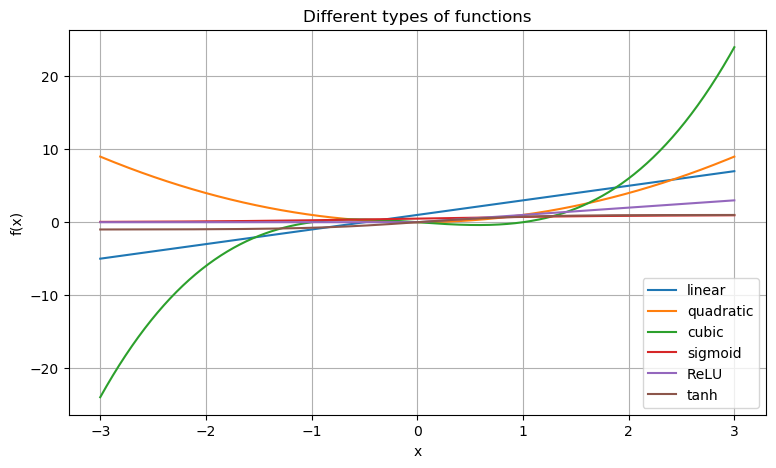

In [2]:
x = np.linspace(-3, 3, 400)

linear = 2 * x + 1
quadratic = x**2
cubic = x**3 - x
sigmoid = 1 / (1 + np.exp(-x))
relu = np.maximum(0, x)
tanh = np.tanh(x)

plt.figure(figsize=(9, 5))
plt.plot(x, linear, label="linear")
plt.plot(x, quadratic, label="quadratic")
plt.plot(x, cubic, label="cubic")
plt.plot(x, sigmoid, label="sigmoid")
plt.plot(x, relu, label="ReLU")
plt.plot(x, tanh, label="tanh")
plt.title("Different types of functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

In [3]:
x_small = np.array([-2, -1, 0, 1, 2], dtype=float)
linear_scores = 1.5 * x_small - 0.5
activated_scores = np.maximum(0, linear_scores)

print("Inputs:", x_small)
print("Result of applying Linear function:", linear_scores)
print("Result of applying ReLU function:", activated_scores)

Inputs: [-2. -1.  0.  1.  2.]
Result of applying Linear function: [-3.5 -2.  -0.5  1.   2.5]
Result of applying ReLU function: [0.  0.  0.  1.  2.5]


<a id=s2></a>
# 2. Function Characteristics

### Important characteristics of a function

When analyzing a function, we often ask:

- what is its **domain**?
- what is its **range**?
- is it increasing or decreasing?
- is it bounded or unbounded?
- is it smooth or not smooth?
- is it convex or non-convex?
- where are its minima or maxima?

These characteristics matter because they tell us how difficult optimization may be.

### Why this matters in ML

In ML, function properties affect:

- whether optimization is easy or hard;
- whether gradients are stable;
- whether there may be many local minima;
- whether the loss surface is smooth enough for gradient-based methods.

For example, a convex smooth function is often easier to optimize than a highly irregular non-convex one.

### Common mistakes

- Confusing continuity with differentiability.
- Assuming every useful ML objective is convex.
- Ignoring the shape of the loss surface.

### ML takeaway

The shape and properties of a function strongly affect how well we can optimize it.

### Quick check

1. Why does smoothness matter in optimization?  
2. Why is convexity useful?  
3. Can a function be continuous but not differentiable?

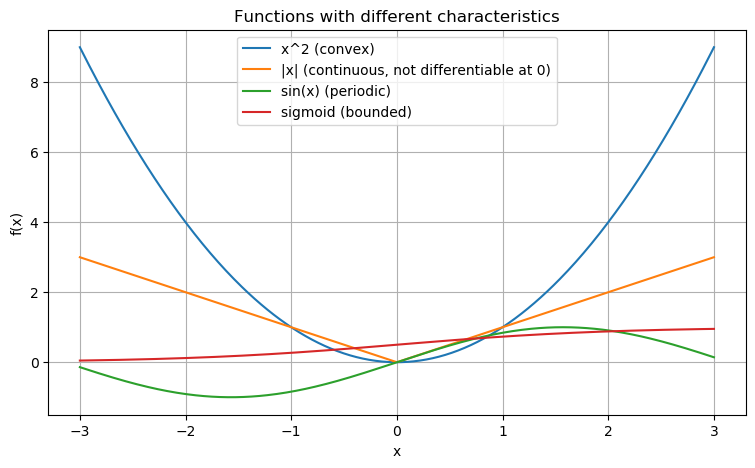

In [5]:
x = np.linspace(-3, 3, 400)
f1 = x**2
f2 = np.abs(x)
f3 = np.sin(x)
f4 = 1 / (1 + np.exp(-x))

plt.figure(figsize=(9, 5))
plt.plot(x, f1, label="x^2 (convex)")
plt.plot(x, f2, label="|x| (continuous, not differentiable at 0)")
plt.plot(x, f3, label="sin(x) (periodic)")
plt.plot(x, f4, label="sigmoid (bounded)")
plt.title("Functions with different characteristics")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

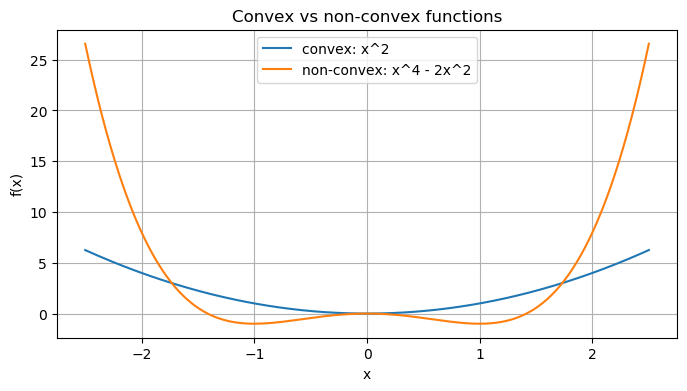

In [6]:
x = np.linspace(-2.5, 2.5, 400)
convex = x**2
nonconvex = x**4 - 2*x**2

plt.figure(figsize=(8, 4))
plt.plot(x, convex, label="convex: x^2")
plt.plot(x, nonconvex, label="non-convex: x^4 - 2x^2")
plt.title("Convex vs non-convex functions")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

<a id=s3></a>
# 3. Limits and Continuity

### Limit

A **limit** describes what value a function approaches as the input approaches some point.

We write

$$
\lim_{x \to a} f(x)
$$

### Continuity

A function is continuous at a point if there is no jump there.

Informally, continuity means the function can be drawn without lifting the pen.

### Why this matters in ML

Continuity matters because:

- optimization methods assume small input changes produce small output changes;
- continuous losses are usually easier to handle numerically;
- discontinuities may create unstable behavior.

Even when functions are not perfectly smooth, continuity often gives a more stable numerical landscape than abrupt jumps.

### Common mistakes

- Thinking continuity and differentiability are the same.
- Ignoring sharp breaks in loss or activation functions.
- Treating numerical instability as only a coding problem.

### ML takeaway

Continuity gives optimization a stable foundation: small moves in input should not create wild jumps in output.

### Quick check

1. What does a limit describe?  
2. Why are discontinuities problematic for optimization?  
3. Does continuity automatically imply differentiability?

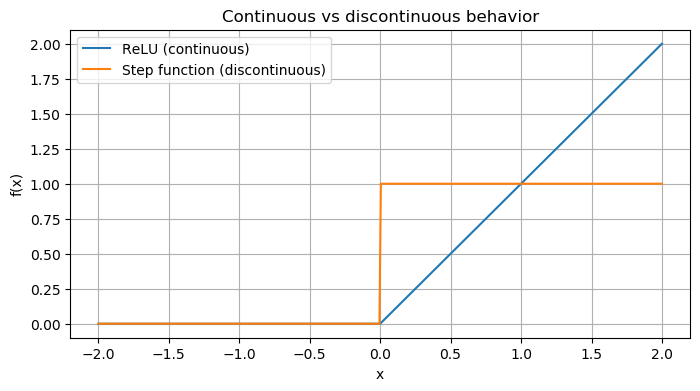

In [7]:
x = np.linspace(-2, 2, 400)
relu = np.maximum(0, x)
step = np.where(x >= 0, 1, 0)

plt.figure(figsize=(8, 4))
plt.plot(x, relu, label="ReLU (continuous)")
plt.plot(x, step, label="Step function (discontinuous)")
plt.title("Continuous vs discontinuous behavior")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()...

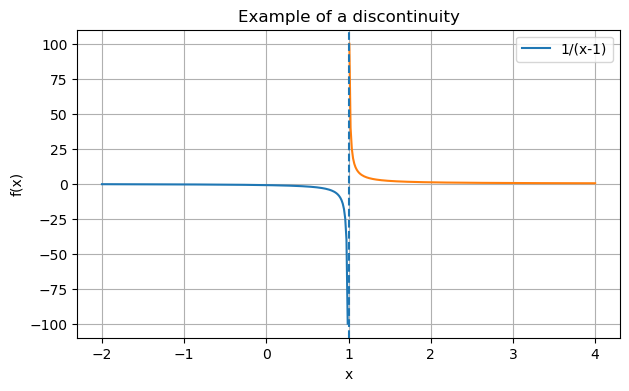

In [8]:
x1 = np.linspace(-2, 0.99, 200)
x2 = np.linspace(1.01, 4, 200)

plt.figure(figsize=(7, 4))
plt.plot(x1, 1/(x1-1), label="1/(x-1)")
plt.plot(x2, 1/(x2-1))
plt.axvline(1, linestyle="--")
plt.title("Example of a discontinuity")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

In [9]:
x_sym = sp.symbols('x')
expr = sp.sin(x_sym) / x_sym

print("Symbolic limit of sin(x)/x as x -> 0:")
display(sp.limit(expr, x_sym, 0))

Symbolic limit of sin(x)/x as x -> 0:


1

<a id=s4></a>
# 4. Extrema of a Function

### What are extrema?

An **extremum** is a point where a function reaches a minimum or maximum.

There are:

- **local minima / maxima**;
- **global minima / maxima**.

### Why this matters in ML

Training a model is usually the search for a **minimum** of a loss function.

That is why extrema are central in ML:

- the best parameter setting is often a minimizer of the loss;
- local minima, saddle points, and flat regions affect training behavior;
- regularization changes the shape of the function being optimized.

In many practical ML problems, especially deep learning, the optimization landscape may contain many stationary points.

### Common mistakes

- Thinking every stationary point is a minimum.
- Assuming the optimizer always finds the global minimum.
- Ignoring saddle points in high-dimensional optimization.

### ML takeaway

Optimization in ML is mainly the problem of finding useful minima of a loss function.

### Quick check

1. What is the difference between a local minimum and a global minimum?  
2. Why are minima more important than maxima in supervised learning?  
3. Can a point have zero derivative and still not be a minimum?

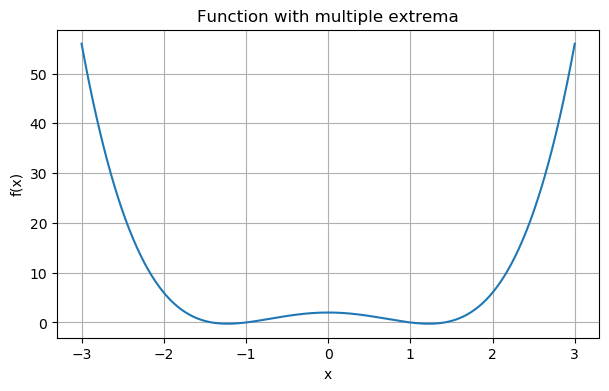

In [10]:
x = np.linspace(-3, 3, 400)
f = x**4 - 3*x**2 + 2

plt.figure(figsize=(7, 4))
plt.plot(x, f)
plt.title("Function with multiple extrema")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

In [11]:
x_sym = sp.symbols('x')
f_sym = x_sym**4 - 3*x_sym**2 + 2
crit_points = sp.solve(sp.diff(f_sym, x_sym), x_sym)

print("Critical points:")
display(crit_points)

print("Second derivative:")
display(sp.diff(f_sym, x_sym, 2))

Critical points:


[0, -sqrt(6)/2, sqrt(6)/2]

Second derivative:


6*(2*x**2 - 1)

<a id=s5></a>
# 5. First and Second Derivatives

### First derivative

The first derivative measures the rate of change of a function.

$$
f'(x)
$$

It tells us how fast the function changes as $x$ changes.

### Second derivative

The second derivative measures how the first derivative changes.

$$
f''(x)
$$

It helps describe curvature.

### Why this matters in ML

- the first derivative tells us the slope;
- the second derivative tells us curvature;
- both are useful for understanding and optimizing loss functions.

If the derivative is positive, the function is increasing.  
If the derivative is negative, the function is decreasing.

The second derivative also helps classify extrema:

- $f''(x) > 0$ often suggests a local minimum;
- $f''(x) < 0$ often suggests a local maximum.

### Common mistakes

- Treating the derivative as only a formal symbol.
- Ignoring that zero slope alone does not identify minima or maxima.
- Forgetting that curvature affects optimization speed and stability.

### ML takeaway

The first derivative points to change, and the second derivative describes the shape of that change.

### Quick check

1. What does the first derivative measure?  
2. What does the second derivative tell us?  
3. Why is curvature useful in optimization?

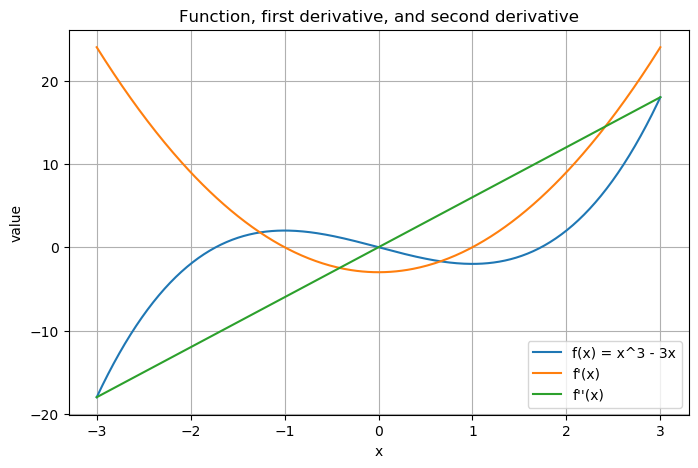

In [14]:
x = np.linspace(-3, 3, 400)
f = x**3 - 3*x
f1 = 3*x**2 - 3
f2 = 6*x

plt.figure(figsize=(8, 5))
plt.plot(x, f, label="f(x) = x^3 - 3x")
plt.plot(x, f1, label="f'(x)")
plt.plot(x, f2, label="f''(x)")
plt.title("Function, first derivative, and second derivative")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()

In [15]:
x0 = 1.0
h = 1e-5
num_derivative = ((x0 + h)**3 - 3*(x0 + h) - (x0**3 - 3*x0)) / h
exact_derivative = 3*x0**2 - 3

print("Numerical derivative at x=1:", num_derivative)
print("Exact derivative at x=1:", exact_derivative)

Numerical derivative at x=1: 3.0000091300053097e-05
Exact derivative at x=1: 0.0


In [21]:
x_sym = sp.symbols('x')
expr = x_sym**3 - 3*x_sym
print("f(x) =")
display(expr)

print("First derivative:")
display(sp.diff(expr, x_sym))

print("Second derivative:")
display(sp.diff(expr, x_sym, 2))

f(x) =


x**3 - 3*x

First derivative:


3*x**2 - 3

Second derivative:


6*x

<a id=s6></a>
# 6. Partial Derivatives

### Why partial derivatives are needed

In machine learning, functions usually depend on many variables.

For example, a loss may depend on many parameters:

$$
L(w_1, w_2, \dots, w_n)
$$

A **partial derivative** measures how the function changes with respect to one variable while the others are held fixed.

For example,

$$
\frac{\partial f}{\partial x}
$$

### Why this matters in ML

Almost every ML model has many parameters, so optimization relies on partial derivatives.

Without partial derivatives, we could not compute parameter updates for multivariable loss functions.

### Common mistakes

- Mixing ordinary and partial derivatives.
- Forgetting which variables are held constant.
- Thinking multivariable optimization is just single-variable calculus repeated blindly.

### ML takeaway

Partial derivatives let us analyze how each parameter individually influences the loss.

### Quick check

1. What does a partial derivative hold fixed?  
2. Why are partial derivatives necessary in ML?  
3. Can a multivariable loss be optimized without understanding partial derivatives?

In [22]:
def f(x, y):
    return x**2 + 3*y**2 + x*y

x = 1.0
y = 2.0

df_dx = 2*x + y
df_dy = 6*y + x

print("f(x, y) =", f(x, y))
print("∂f/∂x =", df_dx)
print("∂f/∂y =", df_dy)

f(x, y) = 15.0
∂f/∂x = 4.0
∂f/∂y = 13.0


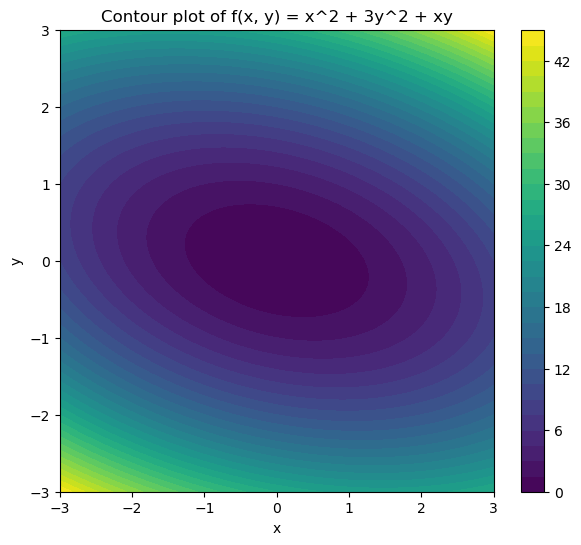

In [23]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 3*Y**2 + X*Y

plt.figure(figsize=(7, 6))
cont = plt.contourf(X, Y, Z, levels=30)
plt.colorbar(cont)
plt.title("Contour plot of f(x, y) = x^2 + 3y^2 + xy")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [24]:
x_sym, y_sym = sp.symbols('x y')
expr2 = x_sym**2 + 3*y_sym**2 + x_sym*y_sym

print("f(x, y) =")
display(expr2)

print("∂f/∂x =")
display(sp.diff(expr2, x_sym))

print("∂f/∂y =")
display(sp.diff(expr2, y_sym))

f(x, y) =


x**2 + x*y + 3*y**2

∂f/∂x =


2*x + y

∂f/∂y =


x + 6*y

<a id=s7></a>
# 7. Gradient

### What is the gradient?

For a scalar function of several variables, the **gradient** is the vector of partial derivatives:

$$
\nabla f(x) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\frac{\partial f}{\partial x_2} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

### Geometric meaning

The gradient points in the direction of **steepest increase**.

That means:

- moving in the gradient direction increases the function most quickly;
- moving in the negative gradient direction decreases it most quickly.

### Why this matters in ML

This is the foundation of gradient-based training.

If a loss function has gradient $\nabla L(w)$, then the negative gradient tells us how to change the parameters to reduce the loss.

### Common mistakes

- Thinking the gradient itself points toward the minimum.
- Forgetting that the gradient is a vector, not a single number.
- Ignoring scale issues when gradients become too small or too large.

### ML takeaway

The gradient is the main local signal that tells an optimizer how to change parameters.

### Quick check

1. In which direction does the gradient point?  
2. Why do we use the negative gradient in optimization?  
3. Is the gradient a scalar or a vector?

In [25]:
def grad_f(x, y):
    return np.array([2*x + y, 6*y + x])

point = np.array([1.0, 2.0])
g = grad_f(point[0], point[1])

print("Point:", point)
print("Gradient at the point:", g)

Point: [1. 2.]
Gradient at the point: [ 4. 13.]


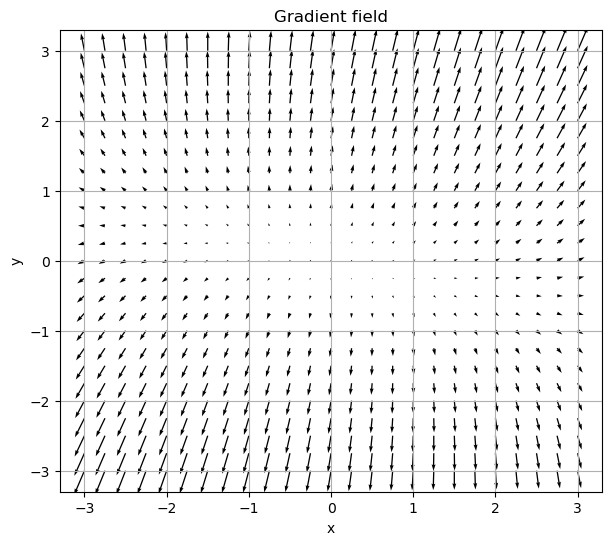

In [26]:
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)

U = 2*X + Y
V = 6*Y + X

plt.figure(figsize=(7, 6))
plt.quiver(X, Y, U, V)
plt.title("Gradient field")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

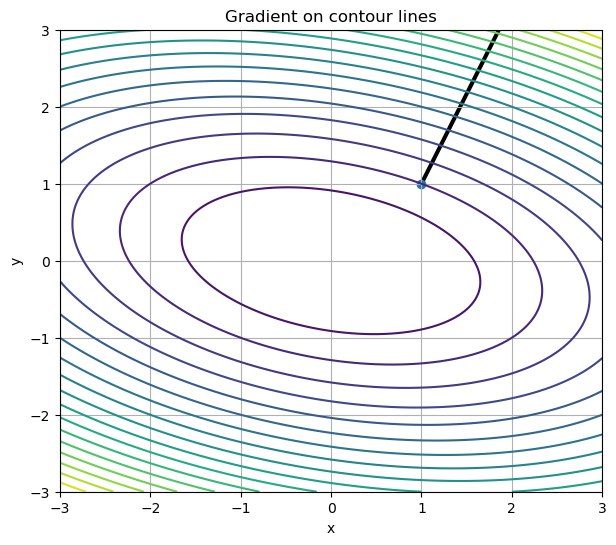

In [27]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 3*Y**2 + X*Y

p = np.array([1.0, 1.0])
g = np.array([2*p[0] + p[1], 6*p[1] + p[0]])

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=20)
plt.quiver(p[0], p[1], g[0], g[1], angles='xy', scale_units='xy', scale=1)
plt.scatter([p[0]], [p[1]])
plt.title("Gradient on contour lines")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

<a id=s8></a>
# 8. Optimization and Gradient Descent

### Optimization in ML

Optimization means finding parameter values that make an objective function as small or as large as needed.

In supervised learning, this usually means minimizing a loss:

$$
\min_w L(w)
$$

### Gradient descent

Gradient descent updates parameters by moving against the gradient:

$$
w_{t+1} = w_t - \eta \nabla L(w_t)
$$

where:

- $w_t$ is the current parameter vector;
- $\eta$ is the learning rate;
- $\nabla L(w_t)$ is the gradient.

### Why this matters in ML

Gradient descent and its variants are the main training mechanism for:

- neural networks;
- logistic regression;
- matrix factorization;
- many other differentiable models.

### Common mistakes

- Using a learning rate that is too large and causing divergence.
- Using a learning rate that is too small and learning too slowly.
- Believing gradient descent guarantees the global optimum in every ML problem.

### ML takeaway

Gradient descent turns local derivative information into a practical learning algorithm.

### Quick check

1. What role does the learning rate play?  
2. Why can a learning rate that is too large be dangerous?  
3. Why is gradient descent iterative?

In [28]:
def loss(w):
    return (w - 3)**2 + 2

def dloss(w):
    return 2*(w - 3)

w = -4.0
lr = 0.1

history_w = [w]
history_l = [loss(w)]

for _ in range(30):
    w = w - lr * dloss(w)
    history_w.append(w)
    history_l.append(loss(w))

print("Final w:", w)
print("Final loss:", loss(w))

Final w: 2.9913344197250025
Final loss: 2.0000750922815023


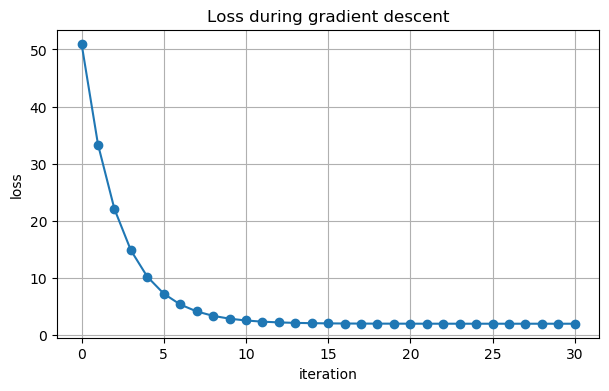

In [29]:
plt.figure(figsize=(7, 4))
plt.plot(history_l, marker="o")
plt.title("Loss during gradient descent")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.grid(True)
plt.show()

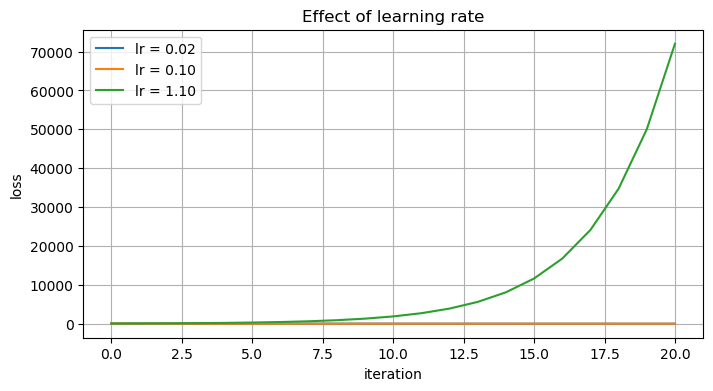

In [30]:
def run_gd(lr, steps=20, w0=-4.0):
    w = w0
    losses = [loss(w)]
    for _ in range(steps):
        w = w - lr * dloss(w)
        losses.append(loss(w))
    return losses

losses_small = run_gd(0.02)
losses_good = run_gd(0.1)
losses_large = run_gd(1.1)

plt.figure(figsize=(8, 4))
plt.plot(losses_small, label="lr = 0.02")
plt.plot(losses_good, label="lr = 0.10")
plt.plot(losses_large, label="lr = 1.10")
plt.title("Effect of learning rate")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.grid(True)
plt.legend()
plt.show()

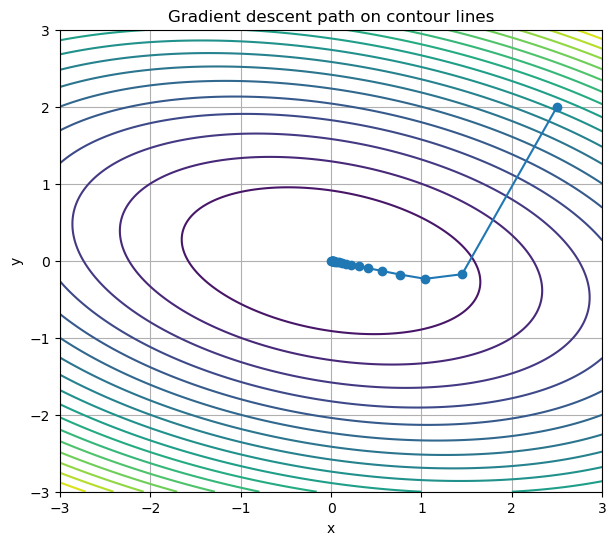

In [31]:
def f2(x, y):
    return x**2 + 3*y**2 + x*y

def grad2(x, y):
    return np.array([2*x + y, x + 6*y])

point = np.array([2.5, 2.0], dtype=float)
lr = 0.15
path = [point.copy()]

for _ in range(20):
    point = point - lr * grad2(point[0], point[1])
    path.append(point.copy())

path = np.array(path)

x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 3*Y**2 + X*Y

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=20)
plt.plot(path[:,0], path[:,1], marker='o')
plt.title("Gradient descent path on contour lines")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

<a id=s9></a>
# 9. Chain Rule

### What is the chain rule?

The chain rule explains how to differentiate a composition of functions.

If

$$
y = f(g(x))
$$

then

$$
\frac{dy}{dx} = f'(g(x)) \cdot g'(x)
$$

### Why this matters in ML

The chain rule is one of the most important ideas in machine learning because deep models are compositions of many functions.

Backpropagation in neural networks is essentially repeated application of the chain rule.

### Common mistakes

- Differentiating outer and inner functions independently without combining them correctly.
- Missing the order of composition.
- Treating backpropagation as a software trick instead of a calculus idea.

### ML takeaway

Without the chain rule, efficient training of deep networks would not be possible.

### Quick check

1. What does the chain rule differentiate?  
2. Why is the chain rule essential for neural networks?  
3. What is backpropagation fundamentally based on?

In [32]:
def g(x):
    return x**2

def f(u):
    return np.sin(u)

x = 1.5
manual = np.cos(g(x)) * (2*x)
print("Chain rule derivative at x=1.5:", manual)

Chain rule derivative at x=1.5: -1.8845208681682175


In [33]:
x_sym = sp.symbols('x')
expr = sp.sin(x_sym**2)
print("Expression:")
display(expr)

print("Derivative:")
display(sp.diff(expr, x_sym))

Expression:


sin(x**2)

Derivative:


2*x*cos(x**2)

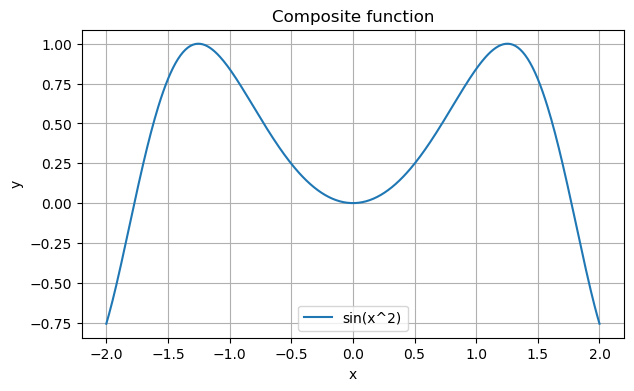

In [34]:
x = np.linspace(-2, 2, 400)
outer_inner = np.sin(x**2)

plt.figure(figsize=(7, 4))
plt.plot(x, outer_inner, label="sin(x^2)")
plt.title("Composite function")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

<a id=s10></a>
# 10. Jacobian

### What is the Jacobian?

When a vector-valued function depends on several variables, its derivatives are organized in the **Jacobian matrix**.

If

$$
F(x) =
\begin{bmatrix}
f_1(x_1, \dots, x_n) \\
f_2(x_1, \dots, x_n) \\
\vdots \\
f_m(x_1, \dots, x_n)
\end{bmatrix}
$$

then the Jacobian is

$$
J =
\begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}
$$

### Why this matters in ML

Jacobians appear in:

- multivariate transformations;
- backpropagation;
- sensitivity analysis;
- normalizing flows and advanced differentiable models.

### Common mistakes

- Confusing the Jacobian with the gradient.
- Forgetting that the gradient is a special case for scalar output.
- Ignoring shape conventions for Jacobians in implementations.

### ML takeaway

The Jacobian generalizes derivative information when a function has multiple outputs.

### Quick check

1. What kind of function leads naturally to a Jacobian?  
2. Is the Jacobian a scalar, vector, or matrix?  
3. Why does it matter in backpropagation?

In [35]:
def jacobian_example(x, y):
    J = np.array([
        [2*x, 1],
        [y, x]
    ], dtype=float)
    return J

J = jacobian_example(2.0, 3.0)
print("Jacobian:")
print(J)

Jacobian:
[[4. 1.]
 [3. 2.]]


In [36]:
x_sym, y_sym = sp.symbols('x y')
F = sp.Matrix([
    x_sym**2 + y_sym,
    x_sym*y_sym
])
vars_ = sp.Matrix([x_sym, y_sym])

print("Vector-valued function F:")
display(F)

print("Jacobian of F:")
display(F.jacobian(vars_))

Vector-valued function F:


Matrix([
[x**2 + y],
[     x*y]])

Jacobian of F:


Matrix([
[2*x, 1],
[  y, x]])

<a id=s11></a>
# 11. Hessian

### What is the Hessian?

For a scalar-valued function of several variables, the **Hessian** is the matrix of second partial derivatives:

$$
H =
\begin{bmatrix}
\frac{\partial^2 f}{\partial x_1^2} & \cdots & \frac{\partial^2 f}{\partial x_1 \partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial^2 f}{\partial x_n \partial x_1} & \cdots & \frac{\partial^2 f}{\partial x_n^2}
\end{bmatrix}
$$

### Why this matters in ML

The Hessian gives curvature information.

This matters because:

- curvature affects optimization speed;
- second-order methods use Hessian information;
- the Hessian helps distinguish minima, maxima, and saddle behavior;
- it helps understand the geometry of a loss surface.

### Common mistakes

- Confusing the Hessian with the Jacobian.
- Thinking curvature does not matter for training.
- Ignoring the computational cost of full Hessians in large models.

### ML takeaway

The Hessian tells us not only where the function changes, but how the slope itself bends.

### Quick check

1. What kind of information does the Hessian provide?  
2. Why can Hessian information improve optimization?  
3. Is the Hessian based on first derivatives or second derivatives?

In [37]:
def hessian_example():
    H = np.array([
        [2, 1],
        [1, 6]
    ], dtype=float)
    return H

H = hessian_example()
print("Hessian:")
print(H)

eigs = np.linalg.eigvals(H)
print("Hessian eigenvalues:", eigs)

Hessian:
[[2. 1.]
 [1. 6.]]
Hessian eigenvalues: [1.7639 6.2361]


In [38]:
x_sym, y_sym = sp.symbols('x y')
expr_h = x_sym**2 + 3*y_sym**2 + x_sym*y_sym

print("Function:")
display(expr_h)

print("Hessian:")
display(sp.hessian(expr_h, (x_sym, y_sym)))

Function:


x**2 + x*y + 3*y**2

Hessian:


Matrix([
[2, 1],
[1, 6]])

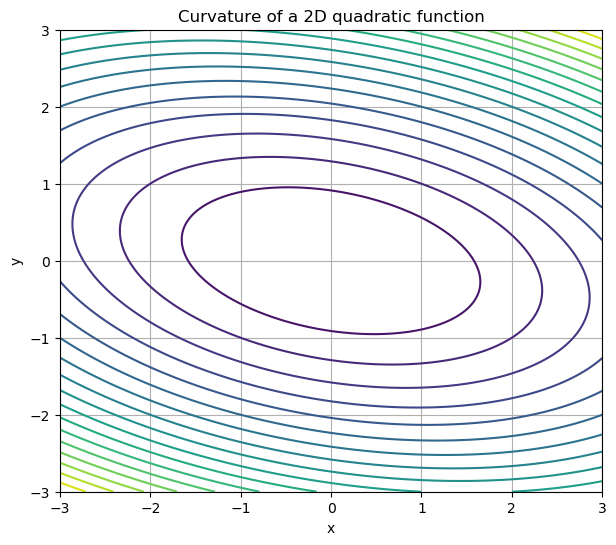

In [39]:
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)
Z = X**2 + 3*Y**2 + X*Y

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=20)
plt.title("Curvature of a 2D quadratic function")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

<a id=s12></a>
# 12. Directional Derivatives and Taylor Intuition

### Directional derivative

A directional derivative measures how the function changes if we move from a point in a specific direction.

If $u$ is a unit direction vector, then the directional derivative is

$$
D_u f(x) = \nabla f(x) \cdot u
$$

### Why this matters in ML

This connects the gradient to movement in parameter space.

It tells us:

- how good a proposed update direction is;
- why the gradient is the direction of steepest increase;
- how optimization behaves locally.

### Taylor intuition

A first-order Taylor approximation says that near a point $x$,

$$
f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x
$$

A second-order approximation adds curvature:

$$
f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x + \frac{1}{2}\Delta x^T H \Delta x
$$

### Why this matters in ML

Taylor approximations help explain:

- why gradient descent works locally;
- how Newton-like methods use curvature;
- why local linear and quadratic approximations are useful in optimization.

### Common mistakes

- Thinking every direction gives the same rate of change.
- Forgetting to normalize the direction when interpreting directional derivatives.
- Missing the connection between local approximation and optimization.

### ML takeaway

Directional derivatives and Taylor approximations explain why local derivative information is so useful for learning algorithms.

### Quick check

1. What does the directional derivative measure?  
2. Why is the gradient connected to the steepest increase direction?  
3. What does the Hessian add to the second-order Taylor approximation?

In [40]:
grad = np.array([4.0, 1.0])
u = np.array([1.0, 2.0])
u = u / np.linalg.norm(u)

directional_derivative = np.dot(grad, u)
print("Gradient:", grad)
print("Unit direction:", u)
print("Directional derivative:", directional_derivative)

Gradient: [4. 1.]
Unit direction: [0.4472 0.8944]
Directional derivative: 2.6832815729997477


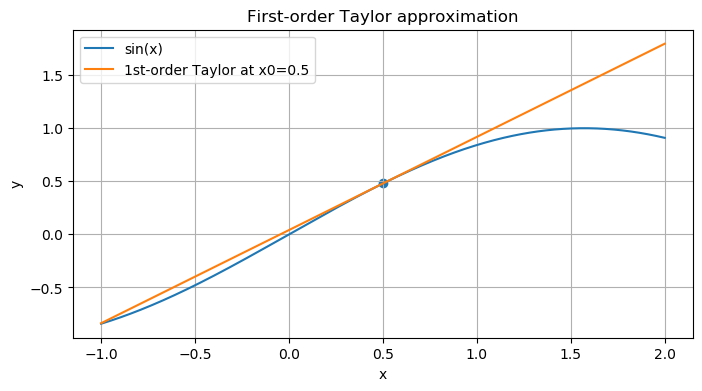

In [41]:
def f(x):
    return np.sin(x)

x0 = 0.5
x = np.linspace(-1, 2, 400)
taylor1 = np.sin(x0) + np.cos(x0) * (x - x0)

plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, taylor1, label="1st-order Taylor at x0=0.5")
plt.scatter([x0], [np.sin(x0)])
plt.title("First-order Taylor approximation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

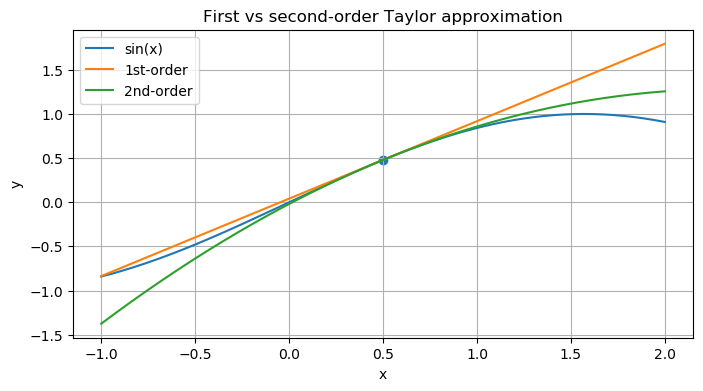

In [42]:
taylor2 = np.sin(x0) + np.cos(x0)*(x - x0) - 0.5*np.sin(x0)*(x - x0)**2

plt.figure(figsize=(8, 4))
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, taylor1, label="1st-order")
plt.plot(x, taylor2, label="2nd-order")
plt.scatter([x0], [np.sin(x0)])
plt.title("First vs second-order Taylor approximation")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

<a id=s13></a>
# 13. Symbolic Calculus with SymPy

### Why SymPy is useful here

When learning calculus for ML, it is often helpful to see both:

- the symbolic derivative;
- the numerical interpretation;
- the geometric picture.

`SymPy` is very useful for:

- computing exact derivatives;
- checking manual solutions;
- computing partial derivatives;
- building Jacobians and Hessians;
- simplifying expressions.

### Common mistakes

- Relying only on symbolic formulas without building geometric intuition.
- Using CAS tools mechanically without understanding the meaning.
- Forgetting that symbolic simplicity and numerical stability are different issues.

### ML takeaway

SymPy is a powerful learning companion: it helps verify calculus operations while you focus on the concepts behind ML optimization.

### Quick check

1. Why is symbolic differentiation helpful when learning ML math?  
2. What can SymPy compute besides ordinary derivatives?  
3. Why is it useful to compare symbolic and numerical results?

In [43]:
x, y = sp.symbols('x y')
expr = sp.exp(-x**2) + sp.log(x**2 + 1)

print("Expression:")
display(expr)

print("Derivative with respect to x:")
display(sp.diff(expr, x))

expr2 = x**2 * sp.sin(y) + y**3
print("Partial derivative with respect to x:")
display(sp.diff(expr2, x))
print("Partial derivative with respect to y:")
display(sp.diff(expr2, y))

Expression:


log(x**2 + 1) + exp(-x**2)

Derivative with respect to x:


-2*x*exp(-x**2) + 2*x/(x**2 + 1)

Partial derivative with respect to x:


2*x*sin(y)

Partial derivative with respect to y:


x**2*cos(y) + 3*y**2

In [44]:
x, y = sp.symbols('x y')
scalar_expr = x**2 + x*y + 3*y**2

grad_expr = sp.Matrix([sp.diff(scalar_expr, x), sp.diff(scalar_expr, y)])
hess_expr = sp.hessian(scalar_expr, (x, y))

vector_expr = sp.Matrix([x**2 + y, x*y, sp.sin(x+y)])
jac_expr = vector_expr.jacobian((x, y))

print("Scalar function:")
display(scalar_expr)
print("Gradient:")
display(grad_expr)
print("Hessian:")
display(hess_expr)

print("Vector-valued function:")
display(vector_expr)
print("Jacobian:")
display(jac_expr)

Scalar function:


x**2 + x*y + 3*y**2

Gradient:


Matrix([
[2*x + y],
[x + 6*y]])

Hessian:


Matrix([
[2, 1],
[1, 6]])

Vector-valued function:


Matrix([
[  x**2 + y],
[       x*y],
[sin(x + y)]])

Jacobian:


Matrix([
[       2*x,          1],
[         y,          x],
[cos(x + y), cos(x + y)]])

<a id=s14></a>
# Cheat sheet

## First derivative

$$
f'(x)
$$

Measures rate of change.

## Second derivative

$$
f''(x)
$$

Measures curvature.

## Partial derivative

$$
\frac{\partial f}{\partial x_i}
$$

Measures change with respect to one variable.

## Gradient

$$
\nabla f(x) =
\begin{bmatrix}
\frac{\partial f}{\partial x_1} \\
\vdots \\
\frac{\partial f}{\partial x_n}
\end{bmatrix}
$$

Direction of steepest increase.

## Gradient descent

$$
w_{t+1} = w_t - \eta \nabla L(w_t)
$$

Basic optimization update.

## Chain rule

$$
\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)
$$

Foundation of backpropagation.

## Jacobian

Matrix of first partial derivatives for vector-valued functions.

## Hessian

Matrix of second partial derivatives for scalar-valued multivariable functions.

## First-order Taylor approximation

$$
f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x
$$

## Second-order Taylor approximation

$$
f(x + \Delta x) \approx f(x) + \nabla f(x)^T \Delta x + \frac{1}{2}\Delta x^T H \Delta x
$$

<a id=s15></a>
# Mini practice

1. Plot a linear, quadratic, sigmoid, tanh, and ReLU function on the same graph.  
2. Find the first and second derivatives of a cubic function and visualize them.  
3. Compute partial derivatives of a simple two-variable function both manually and with SymPy.  
4. Write gradient descent for a one-dimensional quadratic loss and compare several learning rates.  
5. Compute a Jacobian for a two-output function with SymPy.  
6. Compute a Hessian for a two-variable scalar function with SymPy.  
7. Compare first-order and second-order Taylor approximations near a point.

#### [Math for ML - Part 1. Basics of linear algebra & analityc geometry](https://www.kaggle.com/code/kupershtein/math-for-ml-part1-lin-algebra-an-geometry)